/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


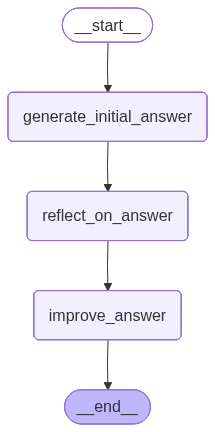


Generating initial answer...


Reflecting on generated answer...


Improving answer based on reflection...


INITIAL DRAFT

Agentic AI, a concept referring to artificial intelligence systems that possess a degree of autonomy and decision-making capabilities, has the potential to significantly transform healthcare. This transformation encompasses various aspects, from operational efficiencies and enhanced patient care to revolutionizing drug discovery and personalized medicine. Below are several key areas where Agentic AI is poised to make a meaningful impact on healthcare.

### 1. **Enhanced Decision-Making in Diagnostics and Treatment**

Agentic AI systems can analyze vast amounts of clinical data quickly and accurately, aiding healthcare professionals in making better-informed decisions. For instance:

- **Diagnostic Support**: AI algorithms can sift through patient records, lab results, and imaging data to help identify conditions such as cancer, cardiovascular diseases, and neurol

In [1]:
"""
=============================================================
FILE 28 — REFLECTION AGENTS
=============================================================

CONCEPTS TAUGHT
----------------
1. Reflection Pattern
2. Self-Critique
3. Recursive Improvement
4. AI Self-Evaluation
5. Iterative Refinement
6. Generator + Critic Architecture
7. Autonomous Revision
8. Feedback Loops
9. Quality Optimization
10. Agentic Self-Improvement

CORE IDEA
----------
The AI generates an answer,
then reflects on its own answer,
then improves it.

FLOW
-----
Generate
   ↓
Reflect / Critique
   ↓
Improve
   ↓
Final Answer

REAL WORLD USE CASES
---------------------
- AI writing assistants
- Coding agents
- Autonomous report generation
- Research assistants
- Self-improving AI systems
"""

# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import os
from dotenv import load_dotenv

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

# ============================================================
# STEP 2 — LOAD ENV VARIABLES
# ============================================================

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# STEP 3 — INITIALIZE LLM
# ============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

# ============================================================
# STEP 4 — DEFINE SHARED STATE
# ============================================================

class State(TypedDict):
    topic: str
    draft: str
    critique: str
    improved_answer: str

# ============================================================
# STEP 5 — GENERATOR NODE
# ============================================================

def generate_initial_answer(state: State):

    """
    First draft generation.
    """

    print("\nGenerating initial answer...\n")

    response = llm.invoke(
        f"""
        Write a detailed explanation about:
        {state['topic']}
        """
    )

    return {
        "draft": response.content
    }

# ============================================================
# STEP 6 — REFLECTION NODE
# ============================================================

def reflect_on_answer(state: State):

    """
    AI critiques its own response.
    """

    print("\nReflecting on generated answer...\n")

    critique = llm.invoke(
        f"""
        Review the following answer critically.

        Identify:
        - missing points
        - clarity issues
        - weak reasoning
        - improvement suggestions

        ANSWER:
        {state['draft']}
        """
    )

    return {
        "critique": critique.content
    }

# ============================================================
# STEP 7 — IMPROVEMENT NODE
# ============================================================

def improve_answer(state: State):

    """
    AI improves using critique.
    """

    print("\nImproving answer based on reflection...\n")

    improved = llm.invoke(
        f"""
        Improve the answer using the critique below.

        ORIGINAL ANSWER:
        {state['draft']}

        CRITIQUE:
        {state['critique']}
        """
    )

    return {
        "improved_answer": improved.content
    }

# ============================================================
# STEP 8 — BUILD GRAPH
# ============================================================

builder = StateGraph(State)

builder.add_node(
    "generate_initial_answer",
    generate_initial_answer
)

builder.add_node(
    "reflect_on_answer",
    reflect_on_answer
)

builder.add_node(
    "improve_answer",
    improve_answer
)

# ============================================================
# STEP 9 — DEFINE EDGES
# ============================================================

builder.add_edge(
    START,
    "generate_initial_answer"
)

builder.add_edge(
    "generate_initial_answer",
    "reflect_on_answer"
)

builder.add_edge(
    "reflect_on_answer",
    "improve_answer"
)

builder.add_edge(
    "improve_answer",
    END
)

# ============================================================
# STEP 10 — COMPILE GRAPH
# ============================================================

graph = builder.compile()

# ============================================================
# STEP 11 — VISUALIZE GRAPH
# ============================================================

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# ============================================================
# STEP 12 — RUN WORKFLOW
# ============================================================

result = graph.invoke(
    {
        "topic": "How Agentic AI can transform healthcare"
    }
)

# ============================================================
# STEP 13 — PRINT RESULTS
# ============================================================

print("\nINITIAL DRAFT\n")
print("=" * 60)
print(result["draft"])

print("\nCRITIQUE\n")
print("=" * 60)
print(result["critique"])

print("\nIMPROVED ANSWER\n")
print("=" * 60)
print(result["improved_answer"])